In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Rows and Columns:")

print(df.shape)

print("\nColumn Names:")

print(df.columns)

print("\nDataset Info:")

df.info()

Rows and Columns:
(7043, 21)

Column Names:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 no

In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.dropna(inplace=True)

print("Cleaned Shape:",df.shape)

Cleaned Shape: (7032, 21)


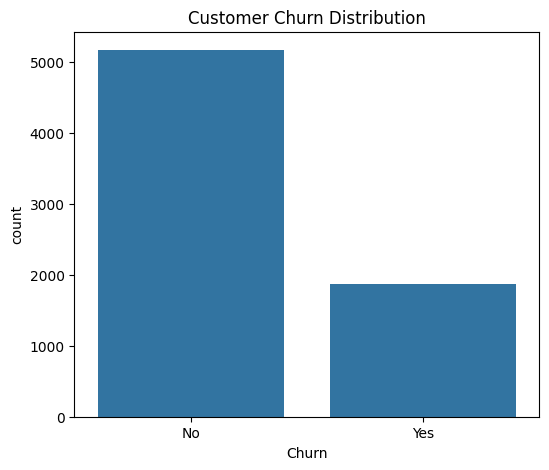

In [6]:
plt.figure(figsize=(6,5))

sns.countplot(x='Churn',data=df)

plt.title("Customer Churn Distribution")

plt.show()

In [7]:
churn_percent = df['Churn'].value_counts(normalize=True)*100

print(churn_percent)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


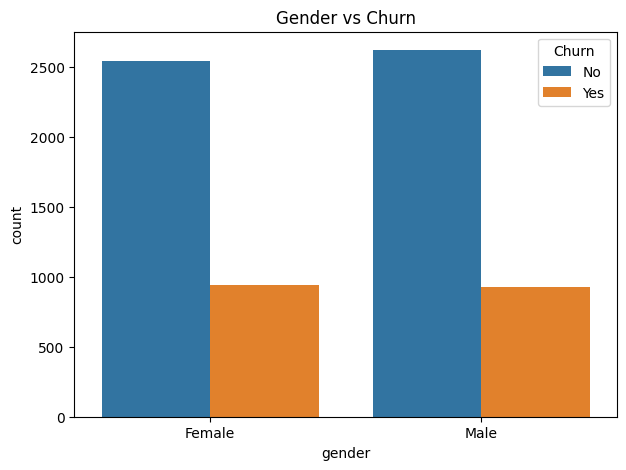

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(x='gender',hue='Churn',data=df)

plt.title("Gender vs Churn")

plt.show()

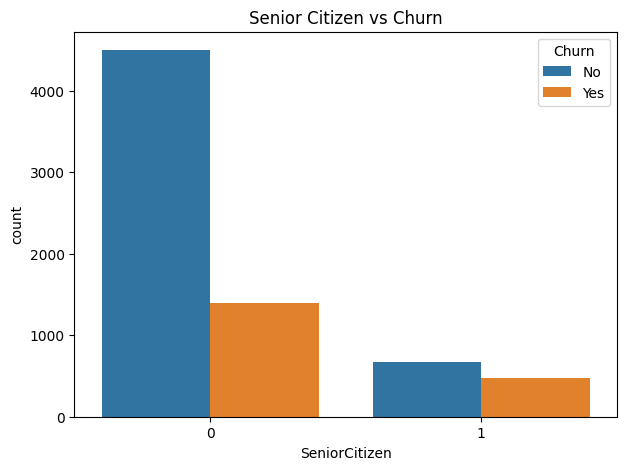

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(x='SeniorCitizen',hue='Churn',data=df)

plt.title("Senior Citizen vs Churn")

plt.show()

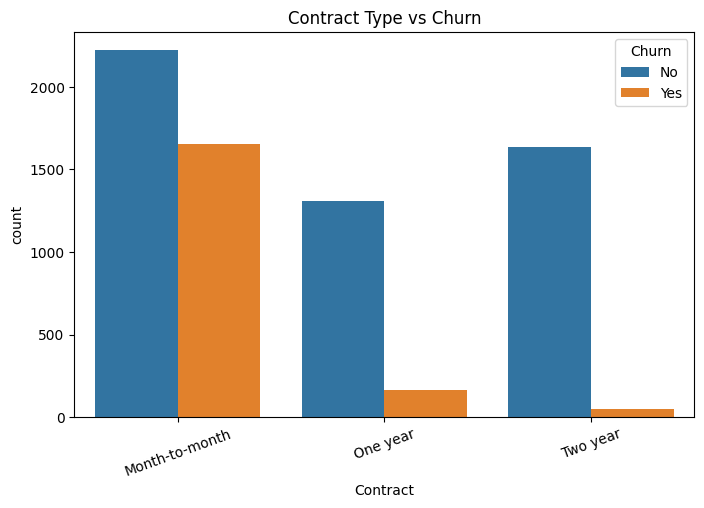

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract',hue='Churn',data=df)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=20)

plt.show()

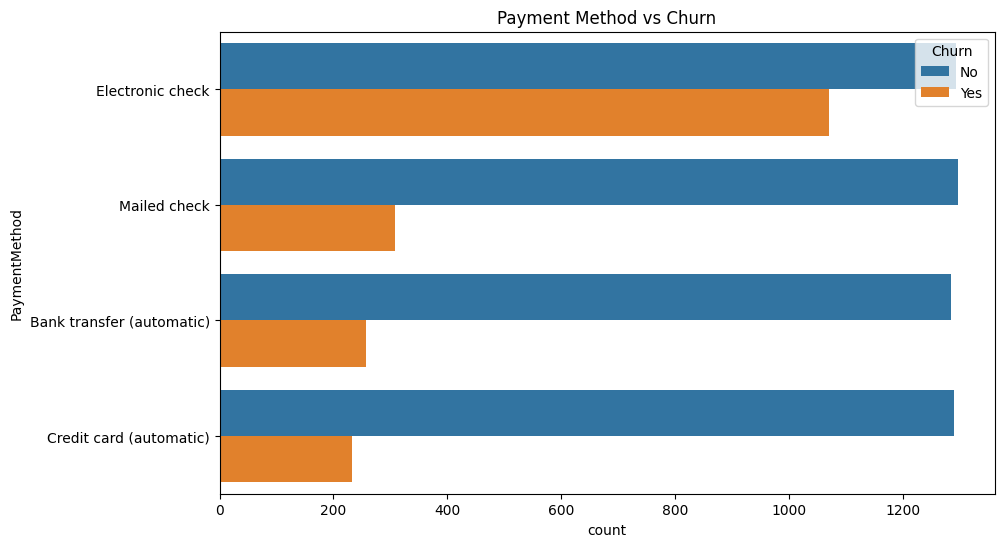

In [11]:
plt.figure(figsize=(10,6))

sns.countplot(y='PaymentMethod',hue='Churn',data=df)

plt.title("Payment Method vs Churn")

plt.show()

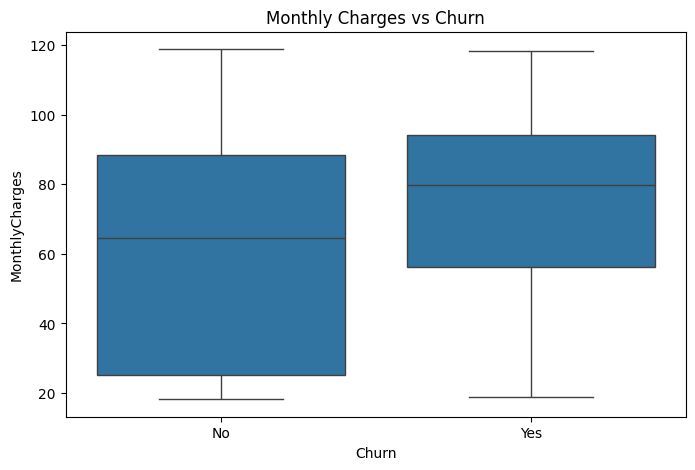

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn',y='MonthlyCharges',data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

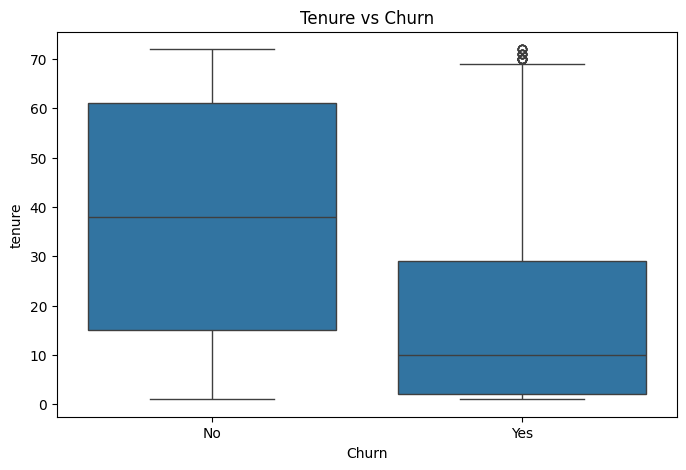

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn',y='tenure',data=df)

plt.title("Tenure vs Churn")

plt.show()

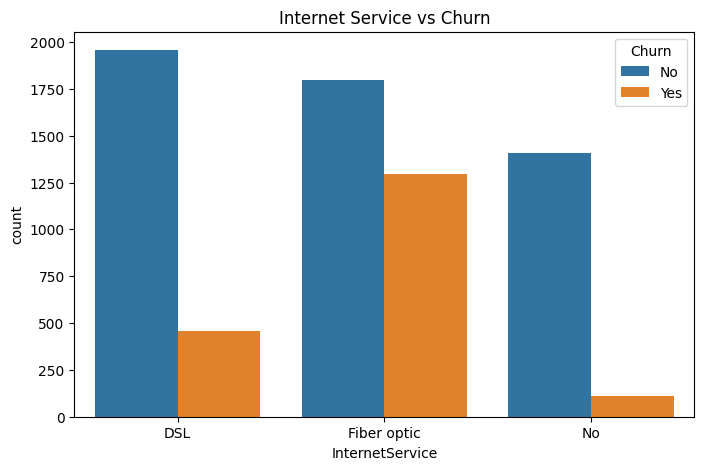

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(x='InternetService',hue='Churn',data=df)

plt.title("Internet Service vs Churn")

plt.show()

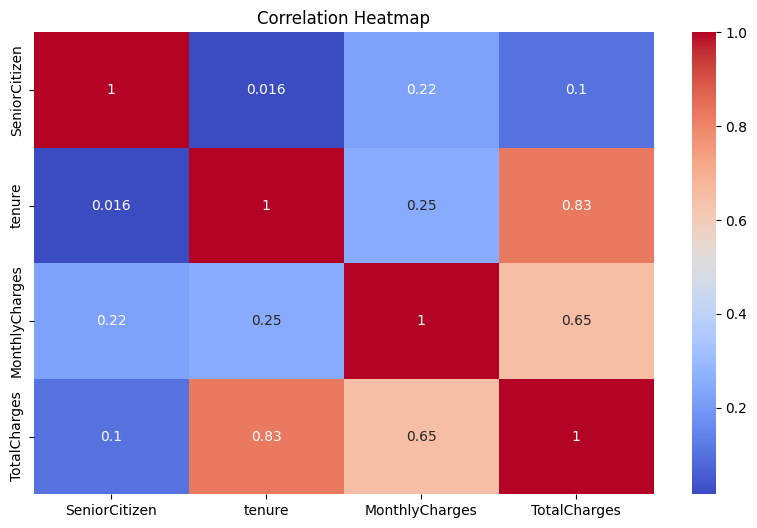

In [15]:
numeric=df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))

sns.heatmap(numeric.corr(),annot=True,cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [16]:
retention = df.groupby('Contract')['tenure'].mean()

print(retention)

Contract
Month-to-month    18.036645
One year          42.073370
Two year          57.071810
Name: tenure, dtype: float64


In [17]:
cohort = df.groupby('PaymentMethod')['MonthlyCharges'].mean()

print(cohort)

PaymentMethod
Bank transfer (automatic)    67.205577
Credit card (automatic)      66.519264
Electronic check             76.255814
Mailed check                 43.958354
Name: MonthlyCharges, dtype: float64


In [18]:
print("BUSINESS INSIGHTS")

print("-------------------------")

print("1. Customers with month-to-month contracts show higher churn.")

print("2. Higher monthly charges increase churn probability.")

print("3. Long-term customers have better retention.")

print("4. Contract type strongly impacts customer loyalty.")

BUSINESS INSIGHTS
-------------------------
1. Customers with month-to-month contracts show higher churn.
2. Higher monthly charges increase churn probability.
3. Long-term customers have better retention.
4. Contract type strongly impacts customer loyalty.


In [19]:
print("PROJECT CONCLUSION")

print("---------------------")

print("This analysis identified key churn drivers, customer retention patterns, and business factors affecting customer loyalty.")

PROJECT CONCLUSION
---------------------
This analysis identified key churn drivers, customer retention patterns, and business factors affecting customer loyalty.
